# 

In [1]:
# Run cell to import libraries and load data sets
import geopandas as gpd 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import contextily 
import mapclassify 
import folium
import aiohttp
import fsspec
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
# Load the COVID-19 data:
df_cases = pd.read_csv("https://raw.githubusercontent.com/babdelfa/project/refs/heads/main/cases_data.csv")
df_deaths = pd.read_csv("https://raw.githubusercontent.com/babdelfa/project/refs/heads/main/deaths_data.csv")    
# Load the GeoDataFrame containing United States geometry shapes (at a county-level):
county_shapes = "https://github.com/babdelfa/gis/blob/main/counties_geometry.zip?raw=true"
with fsspec.open(county_shapes) as counties_file:
    county_shapes = gpd.read_file(counties_file)

Hello. Please enter your name: Ali
Which state's COVID-19 information would you like to see? 
 Enter the state: Maine




COVID-19 in Maine: Key Statistics

Timeline

Day 0 of COVID-19 in Maine: 2020-03-12

Maine Data by Year:
2020 (from 2020-03-12) 
    - Total reported cases: 24226
    - Average daily new cases: 70.15
    - Total reported deaths: 350
    - Average daily new deaths: 1.01

2021
 - Total reported cases: 122528
 - Average daily new cases: 335.71
 - Total reported deaths: 1183
 - Average daily new deaths: 3.24

Overall totals in Maine (as of December 31, 2021):
 - Total Cases: 146754
 - Total Deaths: 1533



Ali, please select a data visualization option for Maine


 1. View four subplots showing COVID-19 trends in Maine (2020-2021):

   * Bar Chart of Daily New Cases
   * Line Chart of Cumulative Cases Trend
   * Bar Chart of Daily New Deaths
   * Line Chart of Cumulative Deaths Trend

 2. View a choropleth map showing total reported cases and deaths by county in 
 Maine as of December 31, 2021.

 Enter your choice (1 or 2): 1


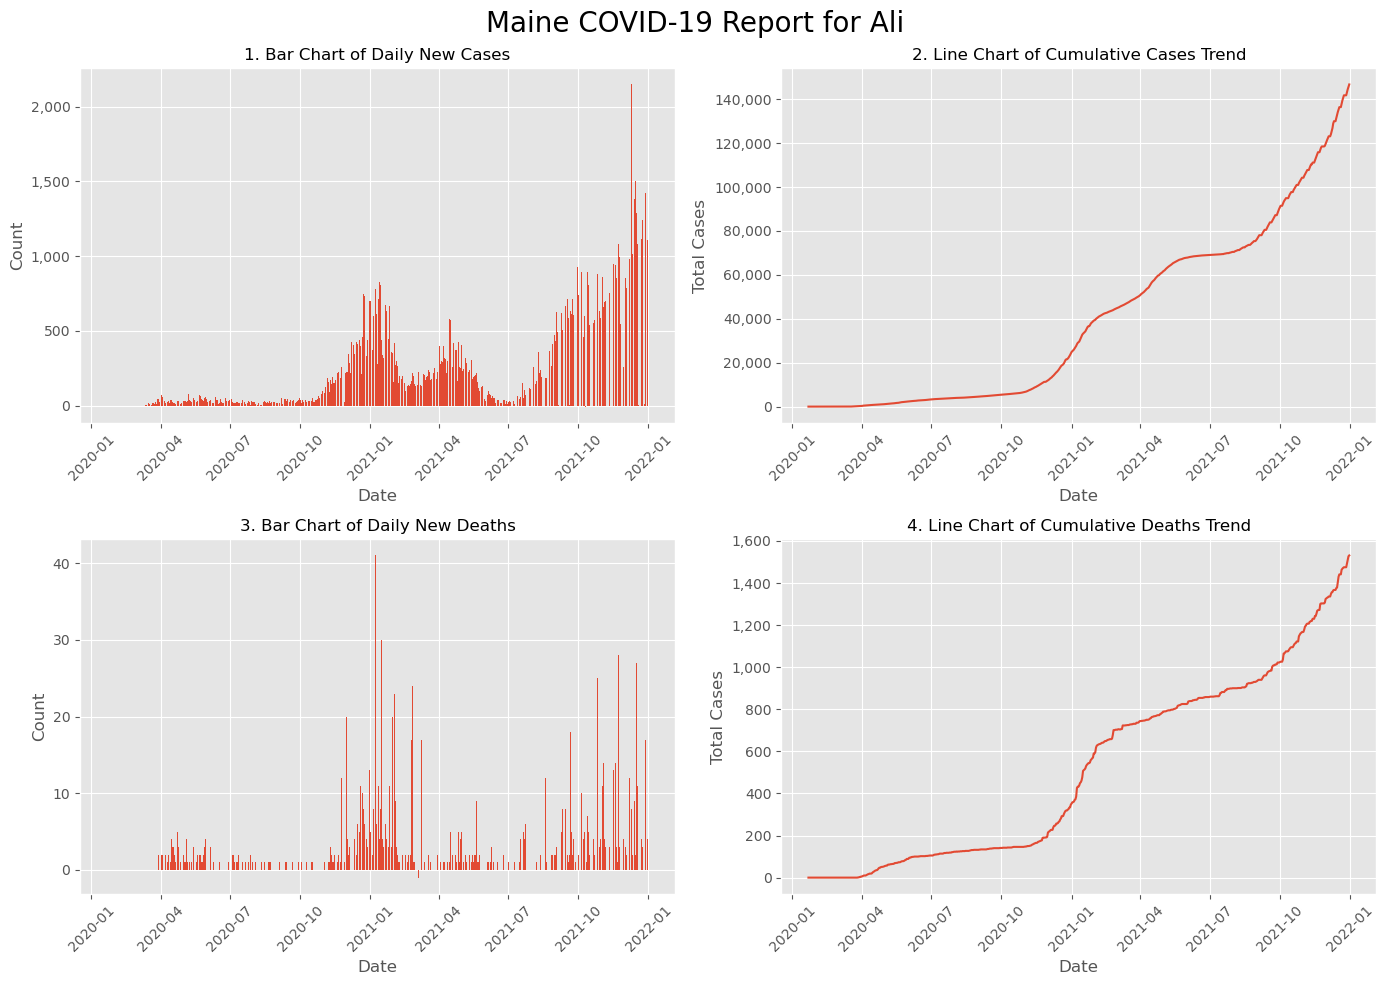

In [3]:
#Dropping, melting, renaming, and adding new columns in cases
#i use _analytics and _map because I dont want them to be mixed up if the analysis changes them
df_cases_analytics = df_cases.drop(columns = ['UID', 'ISO3', 'CODE3', 'FIPS', 'LAT', 'LONG_',])
df_cases_melted = pd.melt(df_cases_analytics, id_vars = ['COUNTY', 'STATE', 'COMBINED_KEY'], var_name= 'Date', value_name='Cases')
df_cases_melted = df_cases_melted.rename(columns={'COUNTY':'County', 'STATE':'State', 'COMBINED_KEY':'County_State'})
df_cases_melted['Date']=pd.to_datetime(df_cases_melted['Date'])
#for the new columns, I grouped by county_state so the .diff() didnt subtract across different counties 
df_cases_melted['New_Cases'] = df_cases_melted.groupby('County_State')['Cases'].diff()

#Dropping, melting, renaming, and adding new columns in deaths
df_deaths_analytics=df_deaths.drop(columns=['iso3', 'fips', 'late', 'long_'])
df_deaths_melted=pd.melt(df_deaths_analytics, id_vars=['county', 'state', 'combined_key', 'population'], var_name='Date', value_name='Deaths')
df_deaths_melted = df_deaths_melted.rename(columns={'county':'County', 'state':'State', 'combined_key':'County_State', 'population':'Population'})
df_deaths_melted['Date']=pd.to_datetime(df_deaths_melted['Date'])
df_deaths_melted['New_Deaths'] = df_deaths_melted.groupby('County_State')['Deaths'].diff()
df_cases_map = df_cases.drop(columns=['UID', 'ISO3', 'CODE3', 'LAT', 'LONG_'])
df_cases_map_melted = pd.melt(df_cases_map, id_vars=['FIPS', 'COUNTY', 'STATE', 'COMBINED_KEY'], var_name='Date', value_name='Cases')
df_cases_map_melted = df_cases_map_melted.rename(columns={'COUNTY':'County', 'STATE':'State', 'COMBINED_KEY':'County_State'})
df_cases_map_melted['Date'] = pd.to_datetime(df_cases_map_melted['Date'])

#Setting it equal to dec 31 2021
dec31_df_cases_map_melted = df_cases_map_melted[df_cases_map_melted['Date']=='2021-12-31']
df_deaths_map = df_deaths.drop(columns=['iso3', 'late', 'long_', 'population'])
df_deaths_map_melted = pd.melt(df_deaths_map, id_vars=['fips', 'county', 'state', 'combined_key'], var_name='Date', value_name='Deaths')

#some end with _d because they repeat with cases df
df_deaths_map_melted = df_deaths_map_melted.rename(columns={'county':'County_d', 'state':'State_d', 'combined_key':'County_State_d'})
df_deaths_map_melted['Date'] = pd.to_datetime(df_cases_map_melted['Date'])
dec31_df_deaths_map_melted = df_deaths_map_melted[df_deaths_map_melted['Date']=='2021-12-31']

#merged twice, first for cases and second for deaths
merged_gdf = pd.merge(county_shapes, dec31_df_cases_map_melted, left_on='FIPS_BEA', right_on='FIPS')
merged_gdf2 = pd.merge(merged_gdf, dec31_df_deaths_map_melted, left_on='FIPS_BEA', right_on='fips')
merged_gdf2 = merged_gdf2.rename(columns={'County':'County Name', 'State':'State Name', 'Cases':'Total Cases', 'Deaths':'Total Deaths'})

#cases/deaths for 2020
df_cases_2020 = df_cases_melted[df_cases_melted['Date']<'2021-1-1']
df_deaths_2020 = df_deaths_melted[df_deaths_melted['Date']<'2021-1-1']

#cases/deaths for 2021
df_cases_2021 = df_cases_melted[df_cases_melted['Date']>='2021-1-1']
df_deaths_2021 = df_deaths_melted[df_deaths_melted['Date']>='2021-1-1']
name_input = input('Hello. Please enter your name:')
state_input = input("""Which state's COVID-19 information would you like to see? 
 Enter the state:""" )
state_cases_2020 = df_cases_2020[df_cases_2020['State'] == state_input]
state_deaths_2020 = df_deaths_2020[df_deaths_2020['State'] == state_input]
state_cases_2021 = df_cases_2021[df_cases_2021['State']== state_input]
state_deaths_2021 = df_deaths_2021[df_deaths_2021['State']== state_input]
bothyear_state_cases = df_cases_melted[df_cases_melted['State']==state_input]
bothyear_state_deaths = df_deaths_melted[df_deaths_melted['State']==state_input]

#gets day 0 by seeing where cumulative cases are first greater than 0 and filters by state input
day0= df_cases_melted[(df_cases_melted['Cases']>0) & (df_cases_melted['State']==state_input)]['Date'].min()

#slices to get rid of 00:00:00
day0=str(day0)[:10]

#cant sum new cases, results in negatives; cant sum cumulative cases columns, results are too high; cant max per state, just gives highest county 
#to get the sums take the highest for each county, then sum those maxes 
#for daily averages group by date, sum then average them
print(f"""

COVID-19 in {state_input}: Key Statistics

Timeline

Day 0 of COVID-19 in {state_input}: {day0}

{state_input} Data by Year:
2020 (from {day0}) 
    - Total reported cases: {state_cases_2020.groupby('County_State')['Cases'].max().sum()}
    - Average daily new cases: {state_cases_2020.groupby('Date')['New_Cases'].sum().mean():.2f}
    - Total reported deaths: {state_deaths_2020.groupby('County_State')['Deaths'].max().sum()}
    - Average daily new deaths: {state_deaths_2020.groupby('Date')['New_Deaths'].sum().mean():.2f}""")

#so the total cases/deaths at the end of 2021 *inside the dataframe* takes into account the ones from 2020 because its cumulative, 
#so we have to subtract the totals of 2020 from 2021 to find the 2021 exclusive number
state_absolute_total_cases = state_cases_2021.groupby('County_State')['Cases'].max().sum()
state_2021_cases_exclusive = state_absolute_total_cases - state_cases_2020.groupby('County_State')['Cases'].max().sum()
state_absolute_total_deaths = state_deaths_2021.groupby('County_State')['Deaths'].max().sum()
state_2021_deaths_exclusive = state_absolute_total_deaths - state_deaths_2020.groupby('County_State')['Deaths'].max().sum()

print(f"""
2021
 - Total reported cases: {state_2021_cases_exclusive}
 - Average daily new cases: {state_cases_2021.groupby('Date')['New_Cases'].sum().mean():.2f}
 - Total reported deaths: {state_2021_deaths_exclusive}
 - Average daily new deaths: {state_deaths_2021.groupby('Date')['New_Deaths'].sum().mean():.2f}""")


print(f"""
Overall totals in {state_input} (as of December 31, 2021):
 - Total Cases: {state_absolute_total_cases}
 - Total Deaths: {state_absolute_total_deaths}""")

cases_for_viz = bothyear_state_cases.groupby(['Date'], as_index=False)['New_Cases'].sum()
deaths_for_viz = bothyear_state_deaths.groupby(['Date'], as_index=False)['New_Deaths'].sum()
state_gdf = merged_gdf2[merged_gdf2['State Name']==state_input]

cumulative_cases_viz = bothyear_state_cases.groupby(['Date'], as_index=False)['Cases'].sum() 
cumulative_deaths_viz = bothyear_state_deaths.groupby(['Date'], as_index=False)['Deaths'].sum() 
viz_choice = input(f"""
{name_input}, please select a data visualization option for {state_input}


 1. View four subplots showing COVID-19 trends in {state_input} (2020-2021):

   * Bar Chart of Daily New Cases
   * Line Chart of Cumulative Cases Trend
   * Bar Chart of Daily New Deaths
   * Line Chart of Cumulative Deaths Trend
   
 2. View a choropleth map showing total reported cases and deaths by county in 
 {state_input} as of December 31, 2021.
 
 Enter your choice (1 or 2):""")

if viz_choice == '1':
    fig, ax = plt.subplots(2,2, figsize=(14,10))
    fig.suptitle(f'{state_input} COVID-19 Report for {name_input}', fontsize=20)
    ax[0,0].bar(cases_for_viz['Date'], cases_for_viz['New_Cases'])
    ax[0,0].set_xlabel('Date')
    ax[0,0].set_ylabel('Count')
    ax[0,0].set_title('1. Bar Chart of Daily New Cases', fontsize=12)
    ax[0,0].tick_params(axis='x', rotation = 45)
    
    ax[0,1].plot(cumulative_cases_viz['Date'], cumulative_cases_viz['Cases'])
    ax[0,1].set_xlabel('Date')
    ax[0,1].set_ylabel('Total Cases')
    ax[0,1].set_title('2. Line Chart of Cumulative Cases Trend', fontsize=12)
    ax[0,1].tick_params(axis='x', rotation = 45)
    
    ax[1,0].bar(deaths_for_viz['Date'], deaths_for_viz['New_Deaths'])
    ax[1,0].set_xlabel('Date')
    ax[1,0].set_ylabel('Count')
    ax[1,0].set_title('3. Bar Chart of Daily New Deaths', fontsize=12)
    ax[1,0].tick_params(axis='x', rotation = 45)
    
    ax[1,1].plot(cumulative_deaths_viz['Date'], cumulative_deaths_viz['Deaths'])
    ax[1,1].set_xlabel('Date')
    ax[1,1].set_ylabel('Total Cases')
    ax[1,1].set_title('4. Line Chart of Cumulative Deaths Trend', fontsize=12)
    ax[1,1].tick_params(axis='x', rotation = 45)
    
    comma_fmt = ticker.StrMethodFormatter('{x:,.0f}')
    ax[0,0].yaxis.set_major_formatter(comma_fmt)
    ax[0,1].yaxis.set_major_formatter(comma_fmt)
    ax[1,0].yaxis.set_major_formatter(comma_fmt)
    ax[1,1].yaxis.set_major_formatter(comma_fmt)
    plt.tight_layout()
    plt.show()
    
elif viz_choice == '2':
    m =state_gdf.explore(column='Total Cases', cmap='YlOrRd', scheme = 'equalinterval', tooltip= ['County Name', 'State Name', 'Total Cases', 'Total Deaths'])
    display(m)
    